# Spike coordination in simultaneously recorded neural pairs

Do two neurons recorded at the same time coordinate their spiking differently
during **interactive-face**, **non-interactive-face** and **object** fixations —
within a region, and across regions?

## What is computed

Every cross-correlation is computed on one fixation's two **unsmoothed 1 ms**
spike trains, over the **±500 ms** window around fixation onset, and only then
averaged. Nothing outside that window enters anything. Cross-correlating
condition-averaged PSTHs would measure shared rate structure, not coordination;
smoothing first would blur the timing this exists to measure.

The correlation is **linear** (zero-padded), the statistic
`scipy.signal.correlate` computes and the one the behavioural
cross-correlations use.

## The null

One null: the **trial shuffle**. Unit A's train on fixation *i* is paired with
unit B's train on some other fixation. Both units keep their fixation-locked
rate profiles and their exact spike counts; only the trial-by-trial covariation
is destroyed. An excess over it means the two cells co-fluctuate from fixation
to fixation.

Each draw is a *derangement* of the fixation index, so the null is built from
exactly as many pairings as the observed statistic. Estimating it from all
`F(F−1)` cross-fixation pairings would shrink its standard error and inflate
every comparison.

## The two measures

| measure | definition | role |
|---|---|---|
| **normalised correlation** | correlation ÷ `sqrt(n_A · n_B)` | headline |
| coincidence count | spike pairs at that lag, per fixation | second measure |

The normalisation is the one `core.signal.normalize_cross_correlation_sqrt_bin_count`
applies to the behavioural cross-correlations — for binary vectors `sqrt(n_x·n_y)`
is exactly `‖x‖·‖y‖`, the cosine normalisation.

**Is it appropriate here?** Partly, and it is worth being precise. It does *not*
equate chance levels across conditions with different firing rates: chance
coincidences grow as `n_A·n_B` while this divides by `sqrt(n_A·n_B)`, so a
higher-rate condition still sits higher. What removes the rate is the **null**,
which carries the same spike counts. And because the normaliser depends only on
spike counts, it cancels exactly in `observed − null` — so this choice sets the
y-axis of the observed plots and changes no statistic.

## How results are reported

Per region for within-region pairs, per region pair for cross-region pairs.
**Nothing is averaged across regions.** With these recordings a pooled number
would be a composition of very unequal region contributions rather than a
summary of them.

Each block runs on all pairs first, then on pairs where **both** units are
FDR-selective (`three_condition_core`).

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.runtime.io.analysis_index import build_analysis_output_dir
from dal_monte_2022_analysis.ephys.analysis import fixation_pair_spike_coordination as psc
from dal_monte_2022_analysis.ephys.plotting import fixation_pair_spike_coordination as viz

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

DATASET_CFG_PATH = repo_root / "configs" / "dataset.yaml"
COORDINATION_CFG_PATH = repo_root / "configs" / "ephys_fixation_pair_spike_coordination.yaml"
cfg = load_config(str(DATASET_CFG_PATH))

SUMMARY_DIR = build_analysis_output_dir(cfg, psc.DEFAULT_OUTPUT_SUBDIR) / "summary"
FIGURE_DIR = build_analysis_output_dir(cfg, psc.DEFAULT_OUTPUT_SUBDIR) / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
figs = viz.PairCoordinationPlotSettings(output_dir=FIGURE_DIR)

MIN_PAIRS = psc.DEFAULT_MIN_PAIRS_FOR_REPORTING

settings = psc.build_pair_spike_coordination_settings_from_config(
    dataset_cfg_path=str(DATASET_CFG_PATH),
    coordination_cfg_path=str(COORDINATION_CFG_PATH),
)
print("summary dir:", SUMMARY_DIR)

summary dir: /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/fixation_pair_spike_coordination/summary


## 1. Build state and summaries

In [2]:
# Submission is opt-in: the array costs real cluster time and a notebook cell is
# easy to re-run by accident. False only reports what is missing.
SUBMIT_JOBS = False
REBUILD_SUMMARIES = True

per_date = psc.ensure_pair_coordination_built(
    settings, submit=SUBMIT_JOBS, wait=True,
    sbatch_path=repo_root / psc.DEFAULT_SBATCH_PATH, repo_root=repo_root,
)
if REBUILD_SUMMARIES:
    _ = psc.run_summary_build(settings)

dates: 42 total, 1 complete, 41 incomplete
sessions: 9 of 417 built (0.03 GB on disk)
incomplete dates: ['01022019', '01032019', '01042019', '01052019', '01062019', '01072019', '01082019', '01092019', '01102019', '01112019', '01132019', '01142019', '01152019', '01162018', '01172018', '01172019', '01192018', '01302018', '02022018', '02042018', '02052018', '02062018', '02072018', '02082018', '02092018', '08242018', '08272018', '08282018', '08292018', '08302018', '08312018', '09042018', '09272018', '09292018', '09302018', '10012018', '10022018', '10032018', '10042018', '10092018', '10102018']

submit=False, so nothing was queued. To build these, run:
    sbatch --array=0-17,19-41 /gpfs/milgram/pi/chang/pg496/repositories/dal_monte_2022_analysis/hpc/ephys/run_fixation_pair_spike_coordination.sbatch
or call this again with submit=True.
no dates flagged for the zero-lag artifact.


summary tables written to /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/fixation_pair_spike_coordination/summary


## 2. What the recordings support

A cross-region pair exists only where both regions were recorded in the **same
session**. All four regions support within-region comparisons; across regions
every well-populated combination involves BLA, ACCg and OFC were never recorded
together, and dmPFC × OFC comes from a handful of sessions. Combinations below
the pair threshold appear in the tables but are excluded from the figures.

Days carrying the zero-lag artifact are removed from everything below.

In [3]:
traces = pd.read_pickle(SUMMARY_DIR / "traces_by_region.pkl")
traces_selective = pd.read_pickle(SUMMARY_DIR / "traces_by_region_selective.pkl")

inventory = pd.read_csv(SUMMARY_DIR / "region_pair_inventory.csv")
display(inventory)

dropped = pd.read_csv(SUMMARY_DIR / "dropped_artifact_dates.csv")
if len(dropped):
    display(Markdown(
        f"**{len(dropped)} date(s) removed for the zero-lag artifact:** "
        f"{sorted(dropped['date'].astype(str))}"
    ))
else:
    display(Markdown("_No date was flagged for the zero-lag artifact._"))

,scope,region_pair,n_pairs,n_pairs_both_selective,n_sessions,n_dates,min_pairs_per_condition,n_conditions,sufficient_pairs,sufficient_selective_pairs
0,cross_region,accg-bla,2440,1168,9,1,666,3,True,True
1,within_region,bla,1320,469,9,1,347,3,False,False
2,within_region,accg,917,533,9,1,258,3,False,True


_No date was flagged for the zero-lag artifact._

# Within region

## 3. Observed correlation and the trial-shuffle null

Regions down, fixation conditions across. The **gap between the two curves** is
the coordination — the observed curve alone is not, since a correlation scales
with the product of the two firing rates.

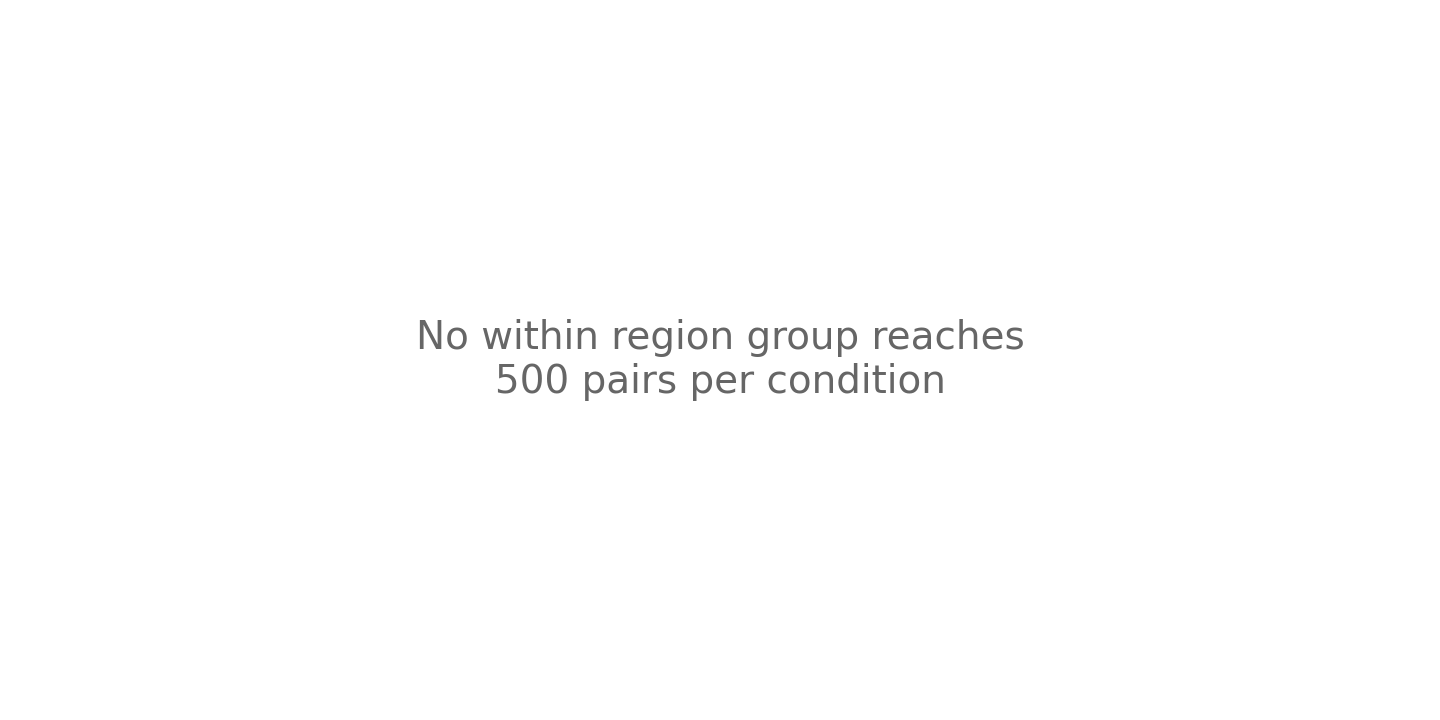

In [4]:
fig, paths = viz.plot_observed_and_null_grid(
    traces, figs, scope="within_region", measure="norm", min_pairs=MIN_PAIRS
)
display(Image(filename=str(paths["png"])))

### The same, for FDR-selective pairs only

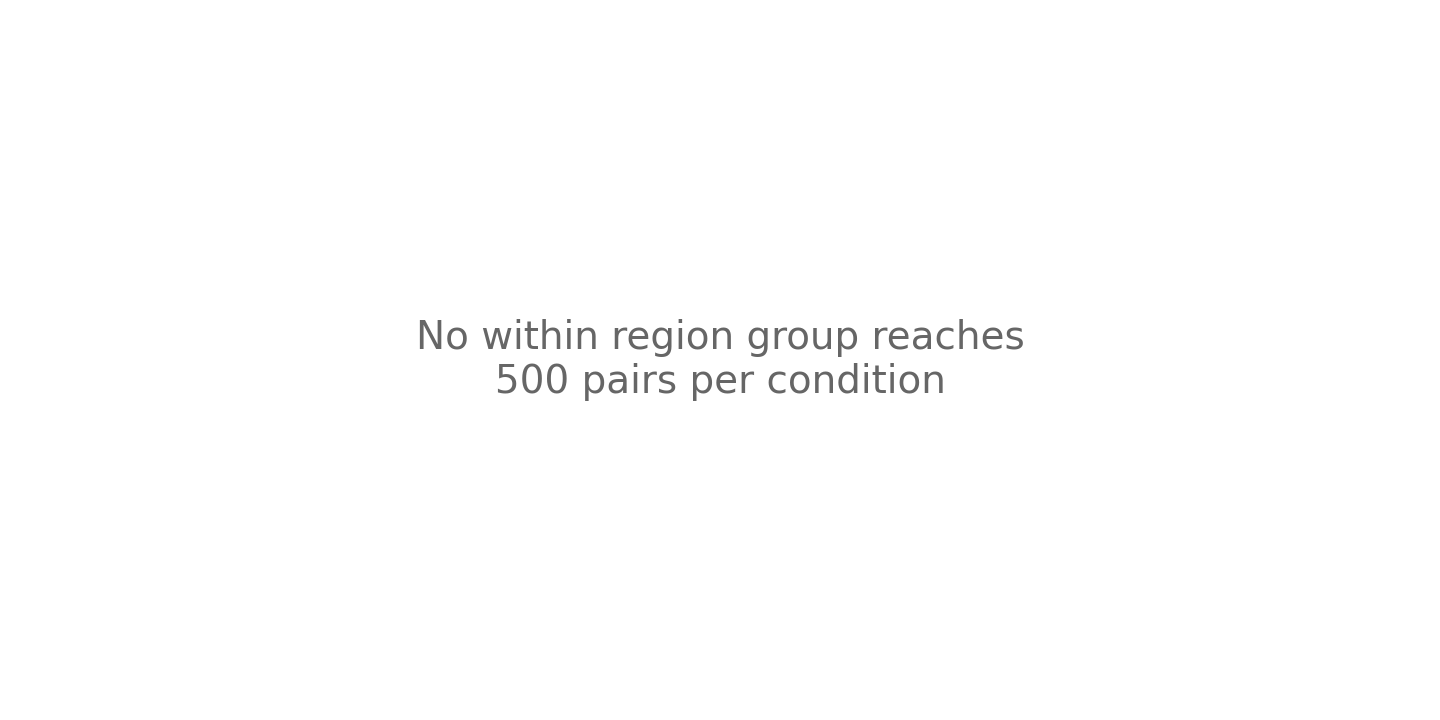

In [5]:
fig, paths = viz.plot_observed_and_null_grid(
    traces_selective, figs, scope="within_region", min_pairs=MIN_PAIRS,
    label="FDR-selective pairs",
)
display(Image(filename=str(paths["png"])))

## 4. Null-corrected coordination, and condition comparisons

Observed minus null, conditions overlaid within each region. Zero means no
coordination beyond what each unit's own fixation-locked rate profile predicts.

The contrasts are **paired within pair**: the same two neurons, electrodes and
session, differing only in which fixations were used. Benjamini–Hochberg
corrected; filled markers survived it.

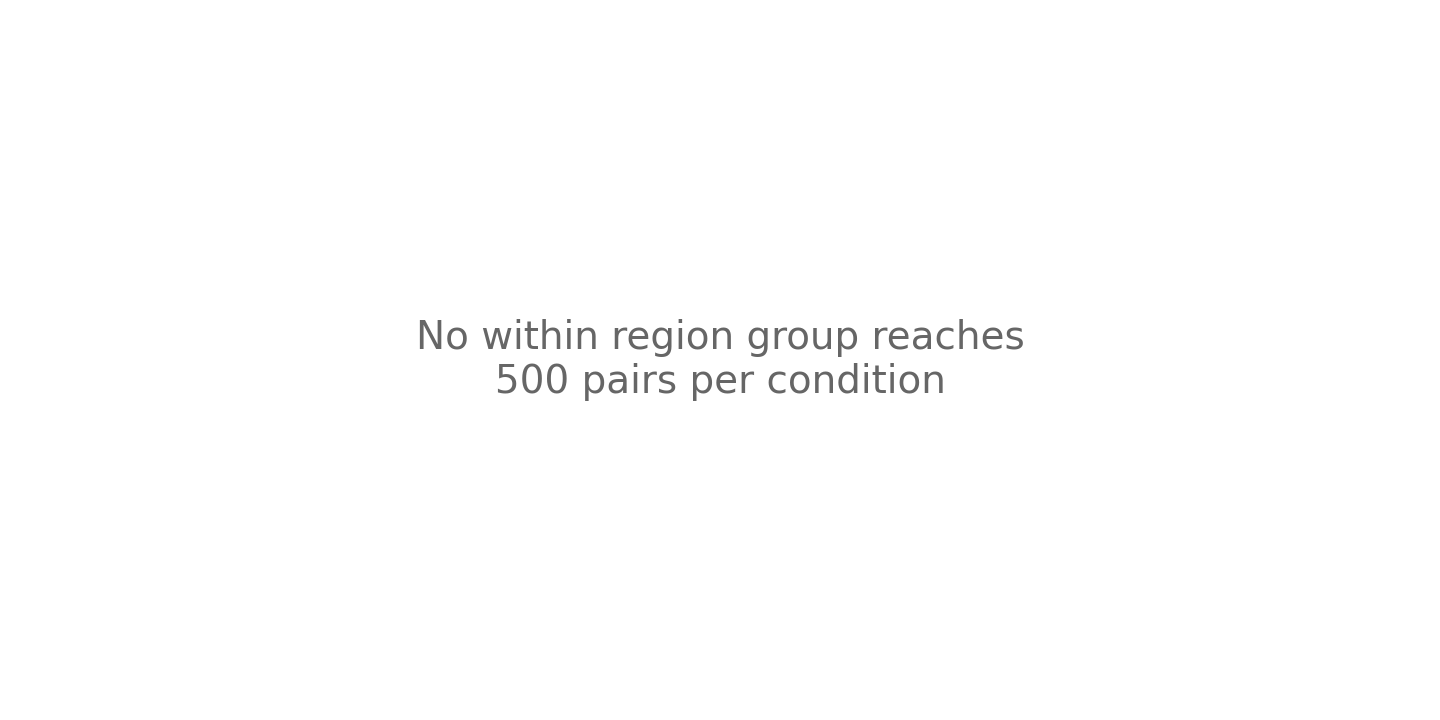

,scope,region_pair,condition_a,condition_b,n_pairs,mean_a,mean_b,mean_difference,statistic,p_value,effect_size_rank_biserial,p_value_corrected,significant,pvalue_correction
3,within_region,accg,face_interactive,face_non_interactive,258,0.0032,0.0045,-0.0013,14076.0,0.0284,-0.0465,0.0511,False,fdr_bh
4,within_region,accg,face_interactive,object,316,0.0037,0.0033,0.0004,20323.0,0.0037,0.1456,0.0111,True,fdr_bh
5,within_region,accg,face_non_interactive,object,258,0.0045,0.0028,0.0016,12541.0,0.0005,0.1628,0.0023,True,fdr_bh
6,within_region,bla,face_interactive,face_non_interactive,318,0.0007,0.0010,-0.0003,24796.0,0.7308,0.0314,0.8222,False,fdr_bh
7,within_region,bla,face_interactive,object,455,0.0010,0.0007,0.0003,44151.0,0.0059,0.0725,0.0134,True,fdr_bh
8,within_region,bla,face_non_interactive,object,328,0.0009,0.0007,0.0002,26970.0,0.9963,-0.0366,0.9963,False,fdr_bh


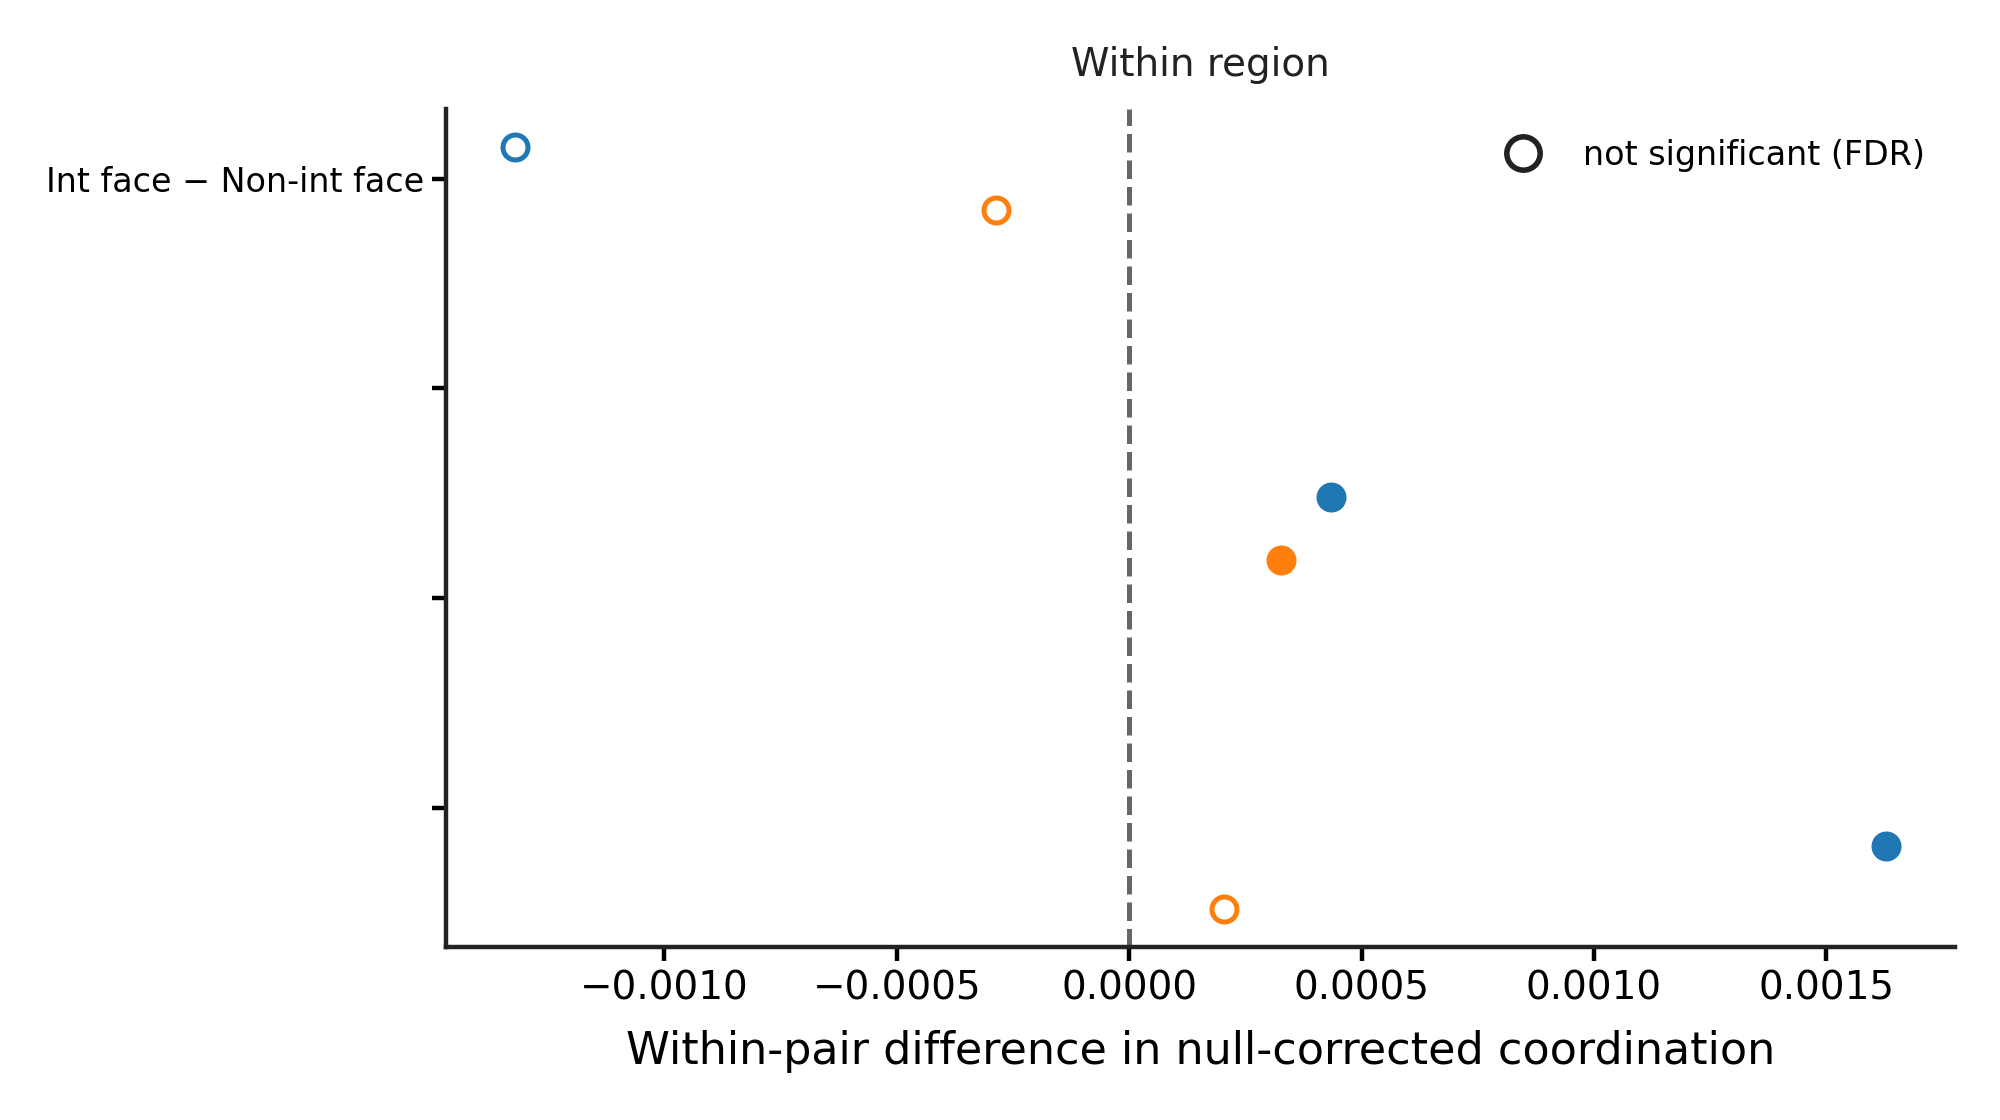

In [6]:
fig, paths = viz.plot_null_corrected_grid(
    traces, figs, scope="within_region", min_pairs=MIN_PAIRS
)
display(Image(filename=str(paths["png"])))

contrasts = pd.read_csv(SUMMARY_DIR / "condition_comparisons_by_region.csv")
display(contrasts.loc[contrasts["scope"] == "within_region"].round(4))

fig, paths = viz.plot_condition_contrasts(contrasts, figs, scope="within_region")
display(Image(filename=str(paths["png"])))

### The same, for FDR-selective pairs only

Selecting units by a condition contrast and then asking whether coordination
differs by condition is circular, so this is a sensitivity check rather than
independent confirmation. What it can show is whether an effect is carried by
the selective subset or is distributed across the population.

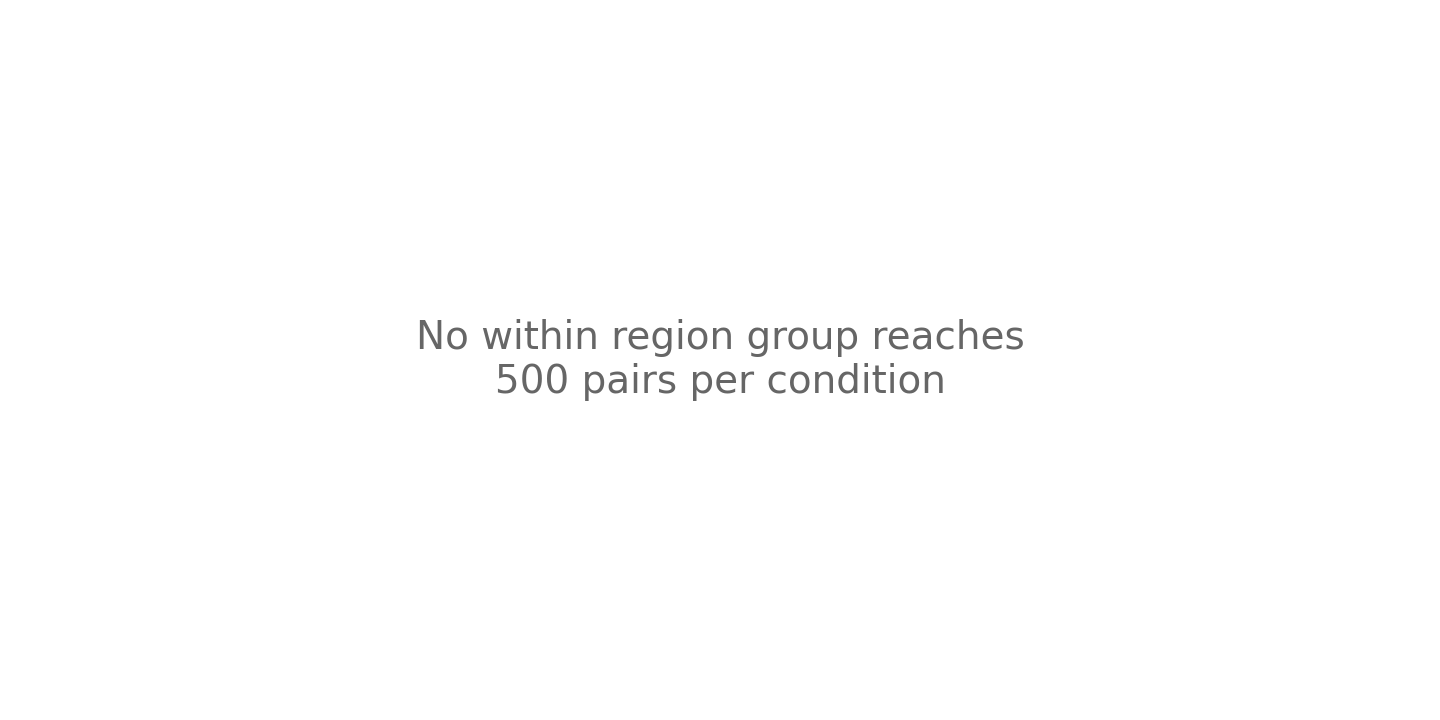

,scope,region_pair,condition_a,condition_b,n_pairs,mean_a,mean_b,mean_difference,statistic,p_value,effect_size_rank_biserial,p_value_corrected,significant,pvalue_correction
3,within_region,accg,face_interactive,face_non_interactive,146,0.0030,0.0045,-0.0015,4440.0,0.0706,-0.0548,0.2118,False,fdr_bh
4,within_region,accg,face_interactive,object,183,0.0037,0.0036,0.0001,7500.0,0.2008,0.0820,0.3614,False,fdr_bh
5,within_region,accg,face_non_interactive,object,146,0.0045,0.0030,0.0015,4240.0,0.0279,0.1096,0.1362,False,fdr_bh
6,within_region,bla,face_interactive,face_non_interactive,121,0.0006,0.0005,0.0001,3286.0,0.2954,0.0909,0.4431,False,fdr_bh
7,within_region,bla,face_interactive,object,159,0.0005,0.0001,0.0004,5430.0,0.1098,0.0818,0.2469,False,fdr_bh
8,within_region,bla,face_non_interactive,object,133,0.0003,0.0002,0.0001,4383.0,0.8707,-0.0827,0.8707,False,fdr_bh


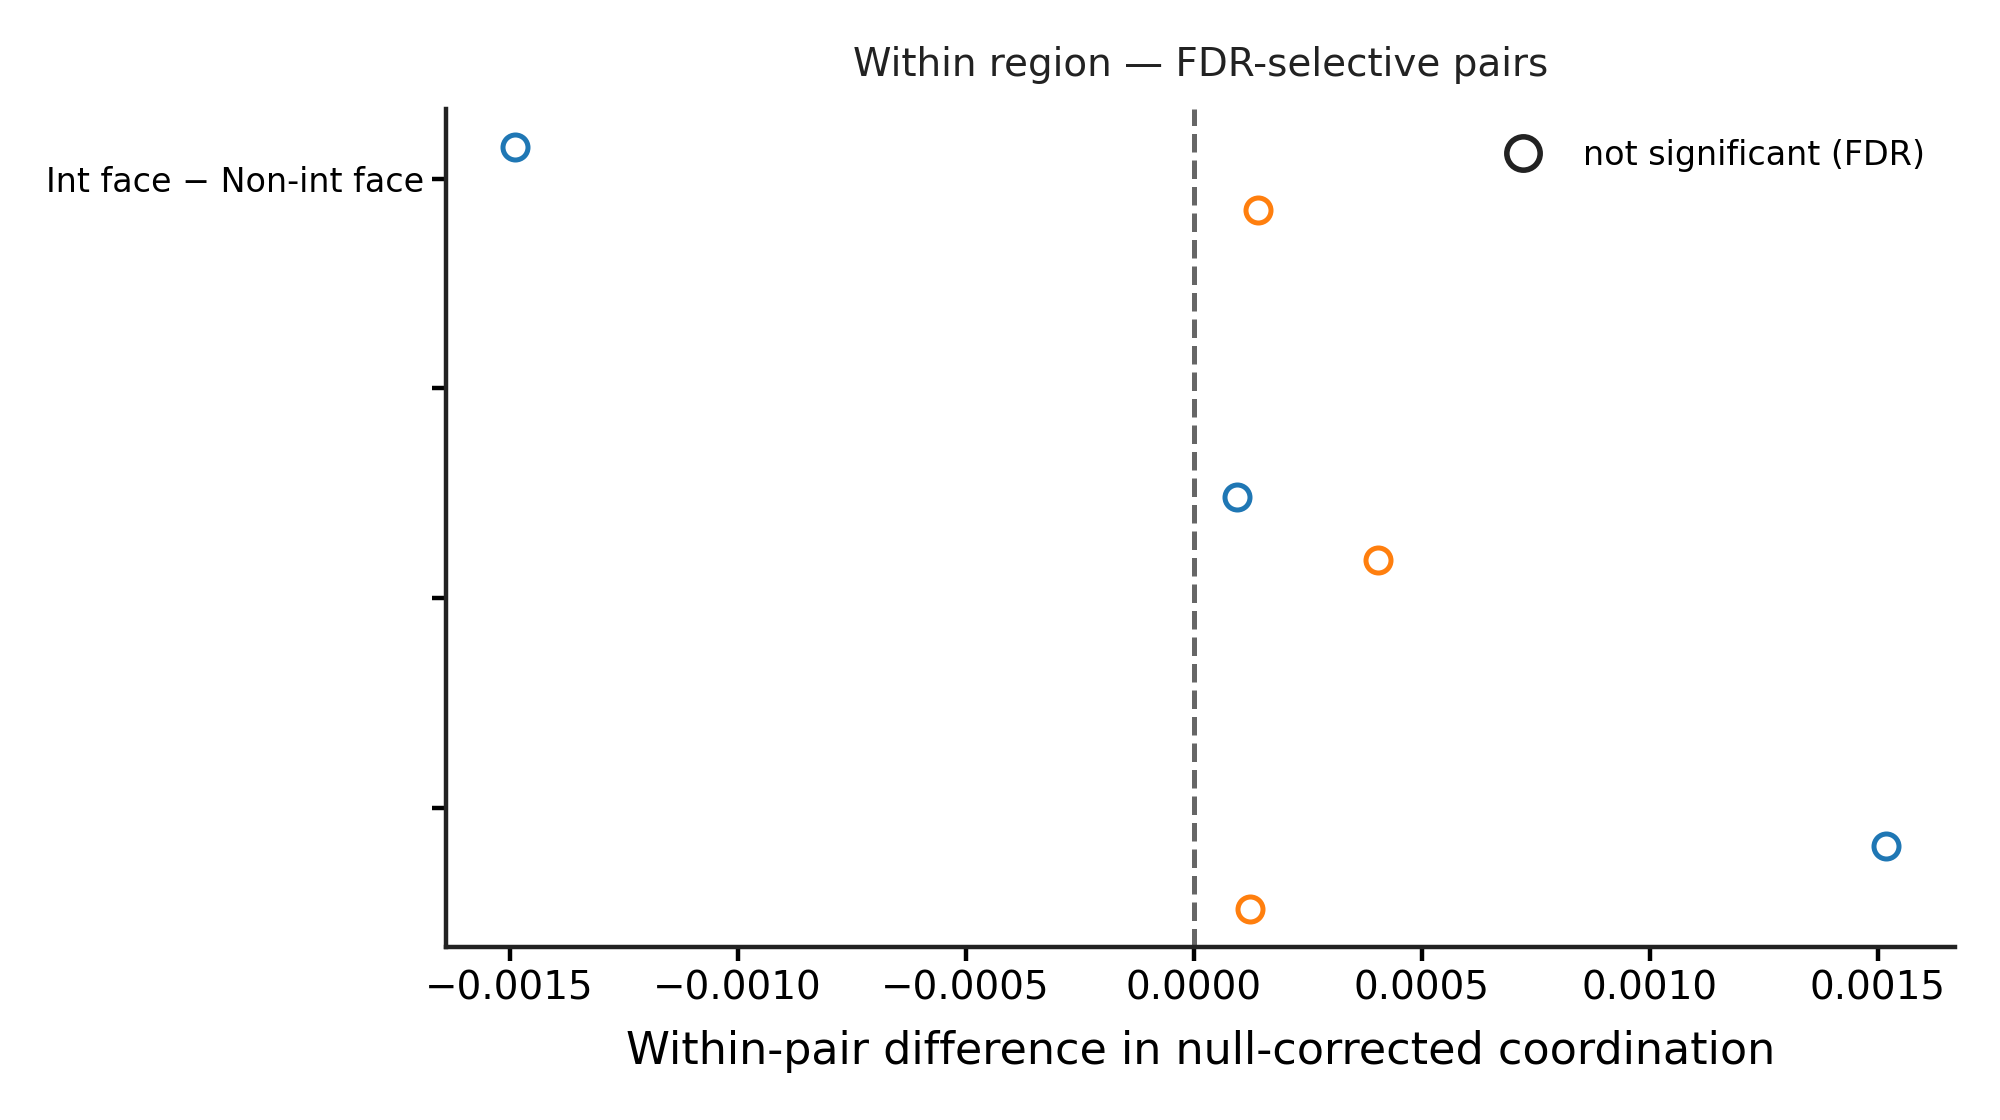

In [7]:
fig, paths = viz.plot_null_corrected_grid(
    traces_selective, figs, scope="within_region", min_pairs=MIN_PAIRS,
    label="FDR-selective pairs",
)
display(Image(filename=str(paths["png"])))

contrasts_selective = pd.read_csv(
    SUMMARY_DIR / "condition_comparisons_by_region_selective.csv"
)
display(contrasts_selective.loc[contrasts_selective["scope"] == "within_region"].round(4))

fig, paths = viz.plot_condition_contrasts(
    contrasts_selective, figs, scope="within_region", label="FDR-selective pairs"
)
display(Image(filename=str(paths["png"])))

# Across regions

## 5. Observed correlation and the trial-shuffle null

All pairs, then FDR-selective pairs.

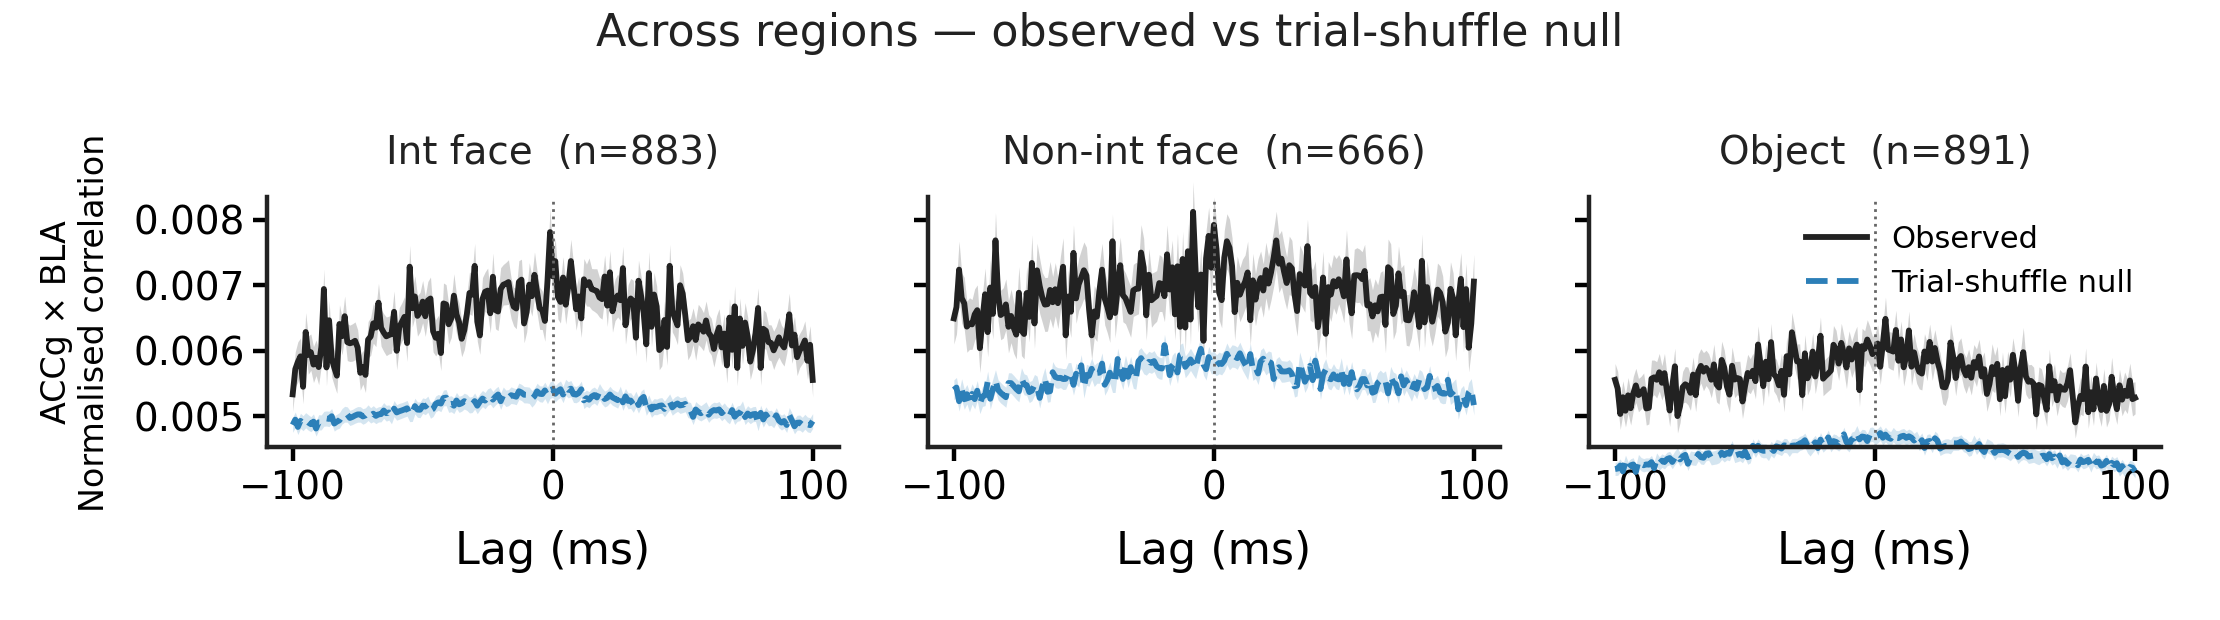

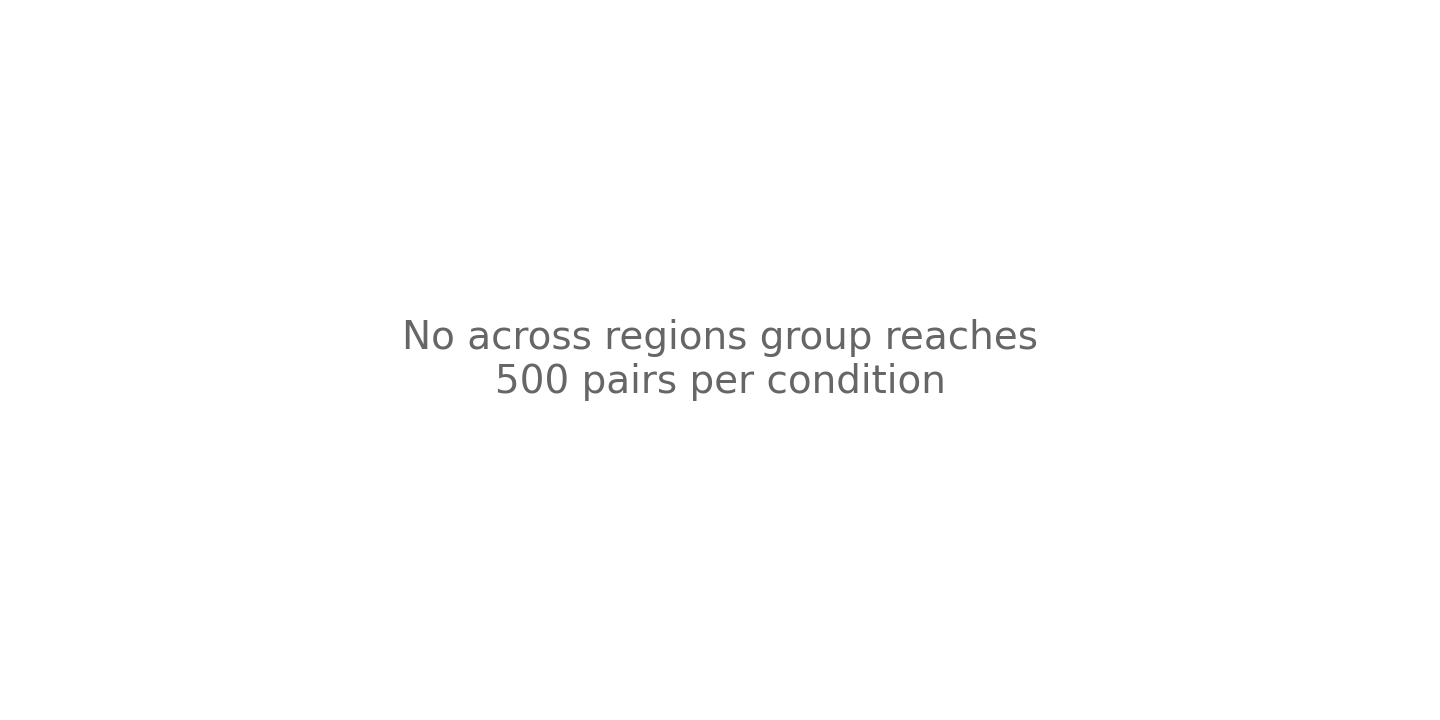

In [8]:
fig, paths = viz.plot_observed_and_null_grid(
    traces, figs, scope="cross_region", min_pairs=MIN_PAIRS
)
display(Image(filename=str(paths["png"])))

fig, paths = viz.plot_observed_and_null_grid(
    traces_selective, figs, scope="cross_region", min_pairs=MIN_PAIRS,
    label="FDR-selective pairs",
)
display(Image(filename=str(paths["png"])))

## 6. Null-corrected coordination, and condition comparisons

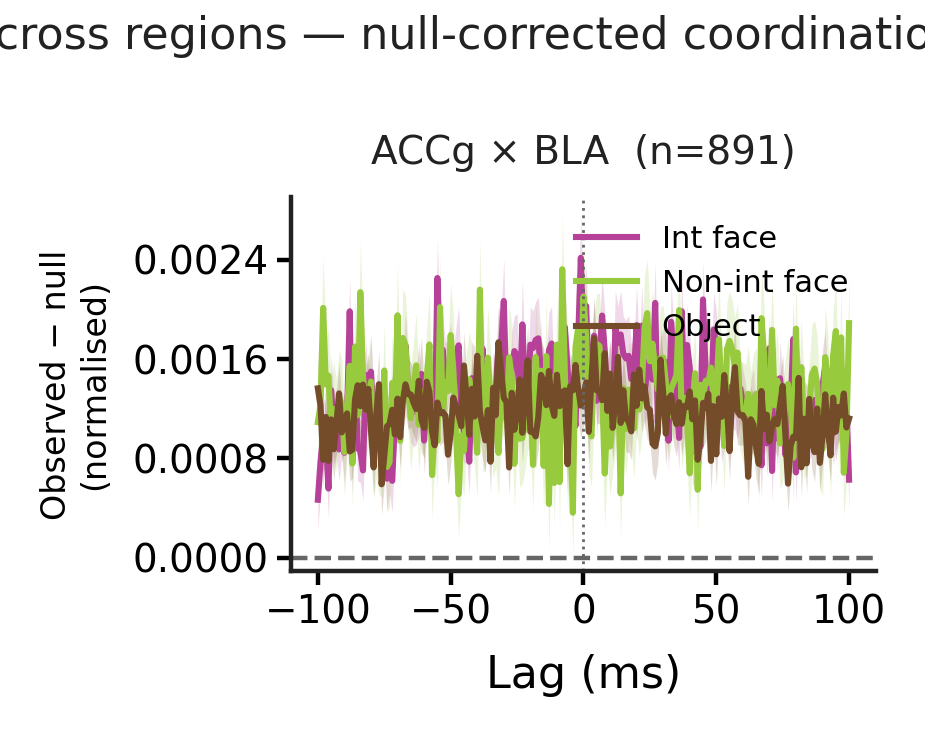

,scope,region_pair,condition_a,condition_b,n_pairs,mean_a,mean_b,mean_difference,statistic,p_value,effect_size_rank_biserial,p_value_corrected,significant,pvalue_correction
0,cross_region,accg-bla,face_interactive,face_non_interactive,639,0.0013,0.0014,-0.0001,92737.0,0.0418,0.1049,0.0627,False,fdr_bh
1,cross_region,accg-bla,face_interactive,object,844,0.0017,0.0014,0.0002,149404.0,0.0000,0.1114,0.0004,True,fdr_bh
2,cross_region,accg-bla,face_non_interactive,object,648,0.0013,0.0013,0.0000,97950.0,0.1316,-0.0864,0.1692,False,fdr_bh


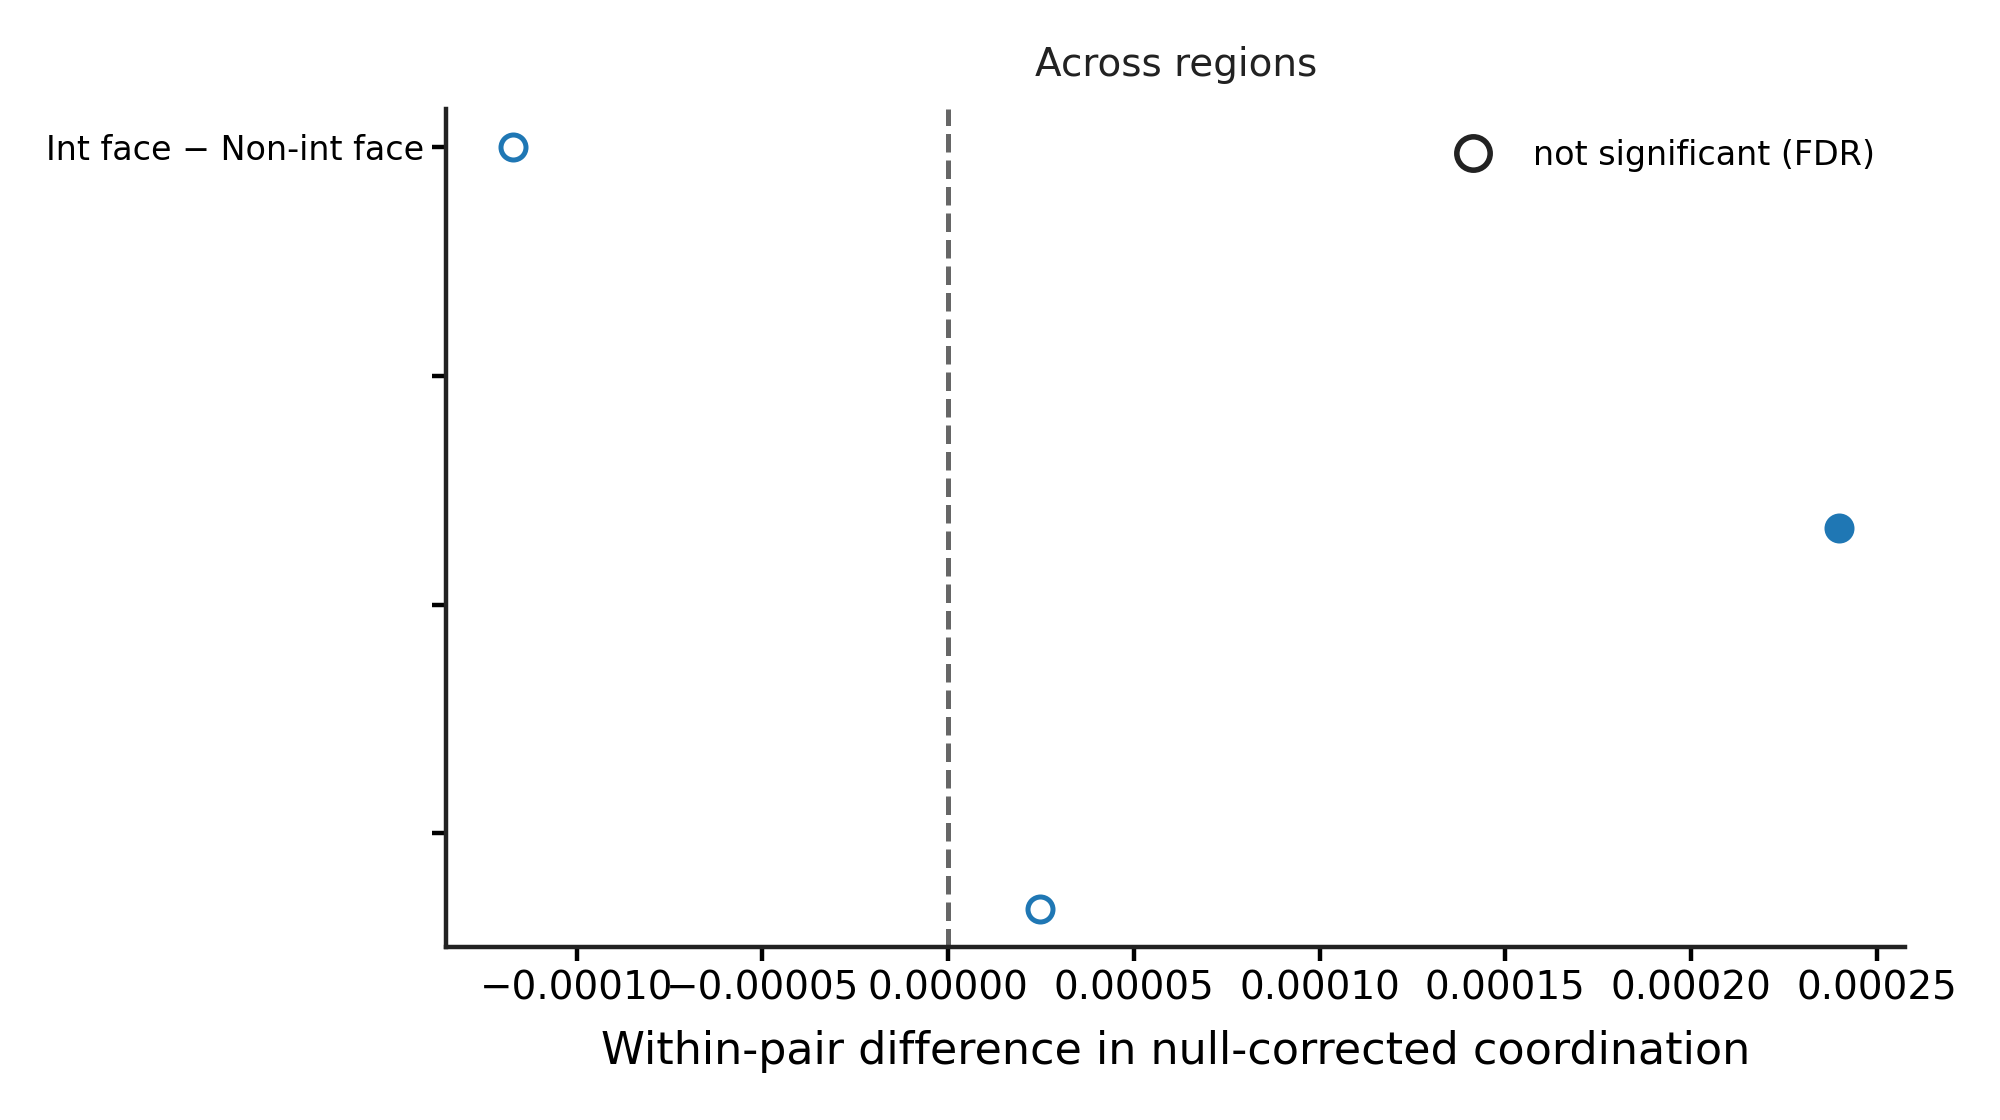

In [9]:
fig, paths = viz.plot_null_corrected_grid(
    traces, figs, scope="cross_region", min_pairs=MIN_PAIRS
)
display(Image(filename=str(paths["png"])))

display(contrasts.loc[contrasts["scope"] == "cross_region"].round(4))
fig, paths = viz.plot_condition_contrasts(contrasts, figs, scope="cross_region")
display(Image(filename=str(paths["png"])))

### The same, for FDR-selective pairs only

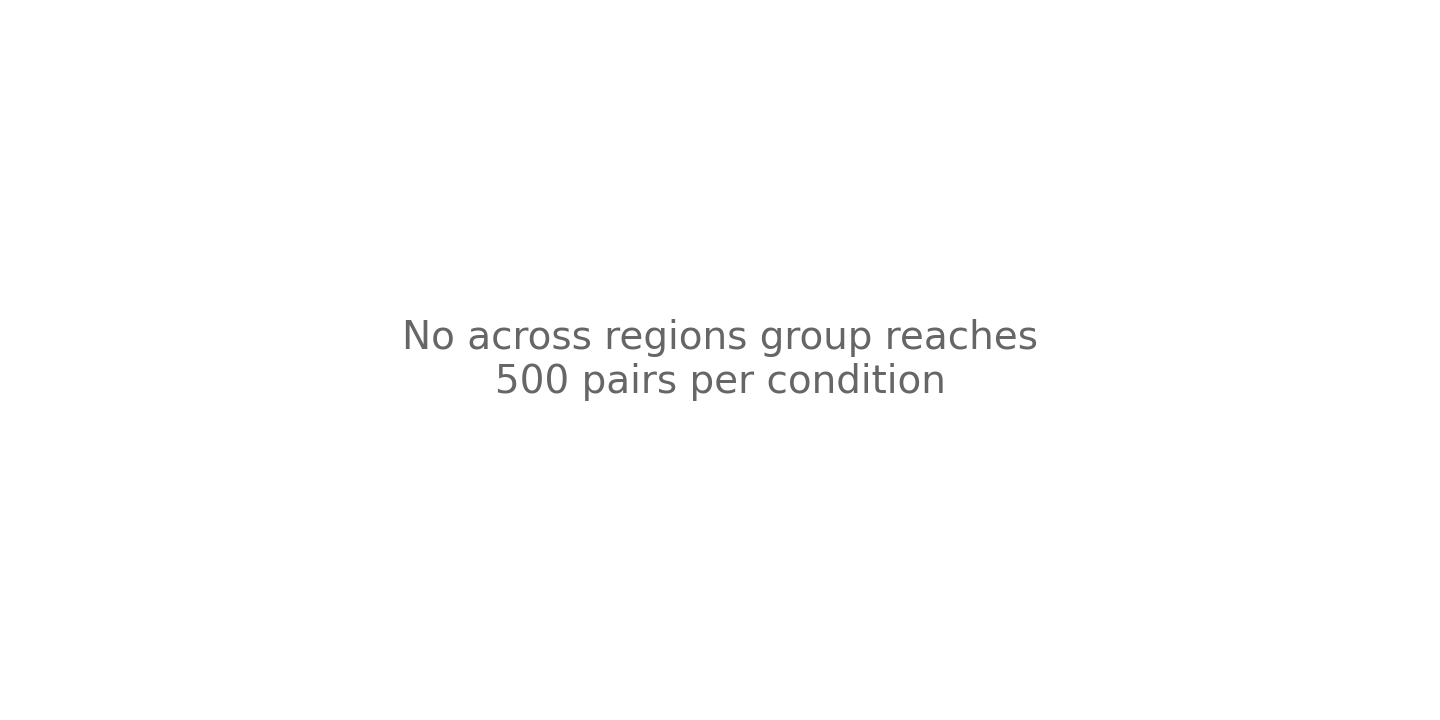

,scope,region_pair,condition_a,condition_b,n_pairs,mean_a,mean_b,mean_difference,statistic,p_value,effect_size_rank_biserial,p_value_corrected,significant,pvalue_correction
0,cross_region,accg-bla,face_interactive,face_non_interactive,312,0.0010,0.0011,-0.0002,23769.0,0.6859,-0.0064,0.8388,False,fdr_bh
1,cross_region,accg-bla,face_interactive,object,400,0.0013,0.0009,0.0005,35087.0,0.0303,0.0900,0.1362,False,fdr_bh
2,cross_region,accg-bla,face_non_interactive,object,326,0.0010,0.0008,0.0003,26098.0,0.7456,-0.0859,0.8388,False,fdr_bh


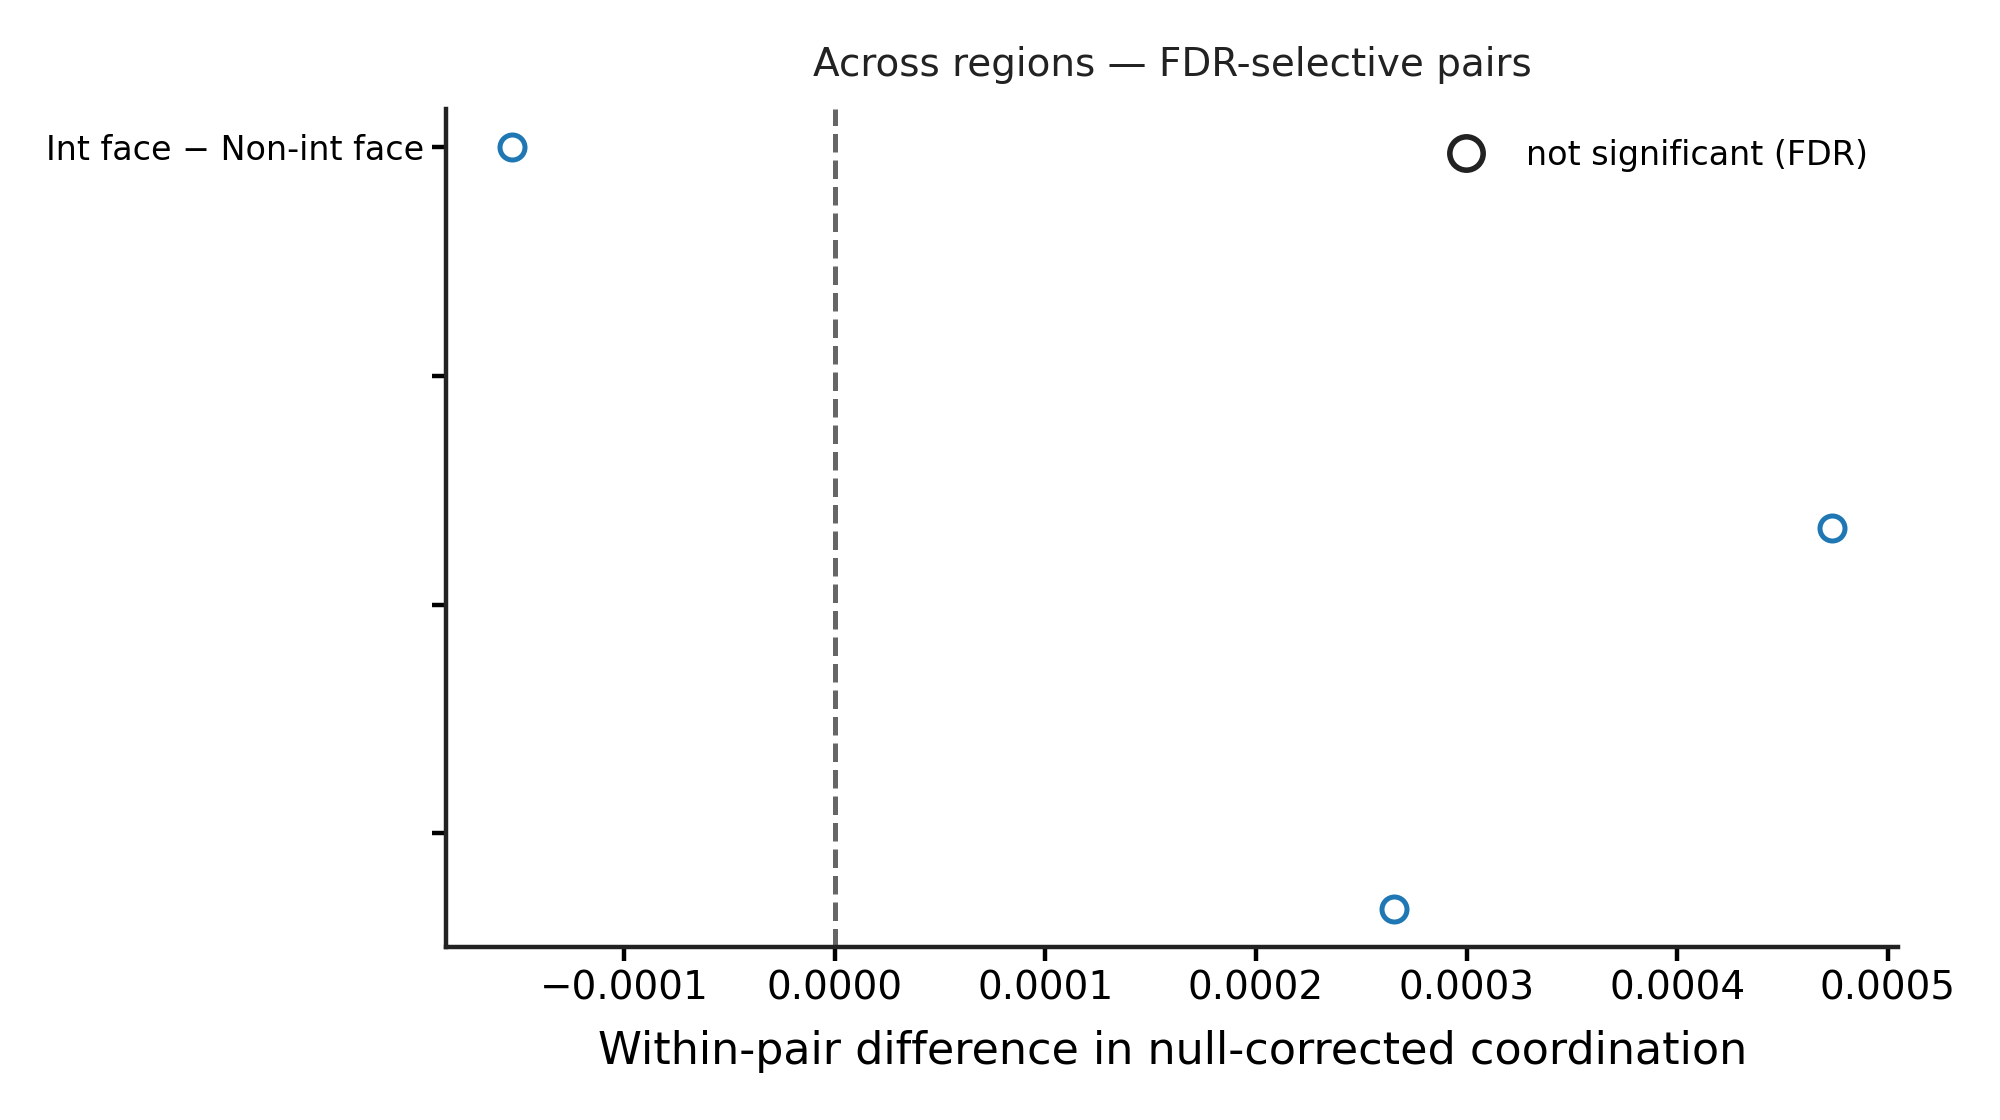

In [10]:
fig, paths = viz.plot_null_corrected_grid(
    traces_selective, figs, scope="cross_region", min_pairs=MIN_PAIRS,
    label="FDR-selective pairs",
)
display(Image(filename=str(paths["png"])))

display(contrasts_selective.loc[contrasts_selective["scope"] == "cross_region"].round(4))
fig, paths = viz.plot_condition_contrasts(
    contrasts_selective, figs, scope="cross_region", label="FDR-selective pairs"
)
display(Image(filename=str(paths["png"])))

# Supporting

## 7. Second measure: raw coincidence counts

The same null-corrected comparison in coincidences per fixation rather than
normalised units, with the two sets of contrasts side by side. A conclusion that
holds in one measure and not the other is a conclusion about the normalisation,
not about the neurons.

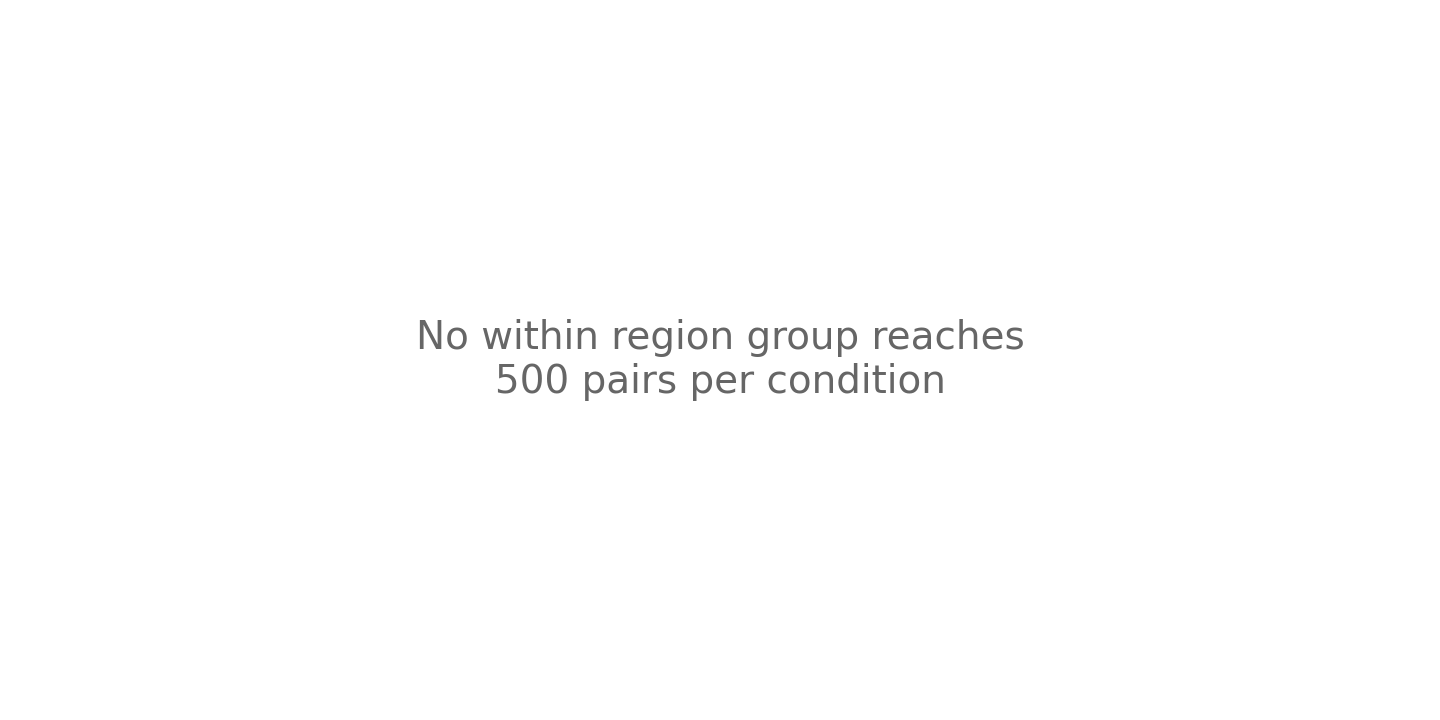

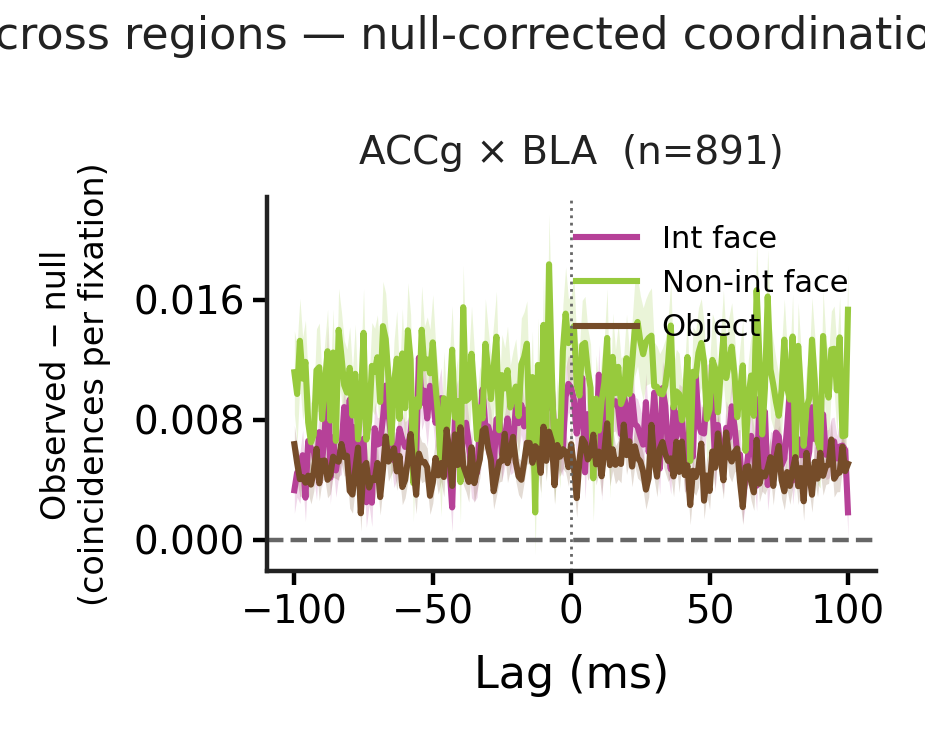

,scope,region_pair,condition_a,condition_b,mean_difference_norm,significant_norm,mean_difference_count,significant_count
0,cross_region,accg-bla,face_interactive,face_non_interactive,-0.0001,False,-0.0030,False
1,cross_region,accg-bla,face_interactive,object,0.0002,True,0.0023,True
2,cross_region,accg-bla,face_non_interactive,object,0.0000,False,0.0045,False
3,within_region,accg,face_interactive,face_non_interactive,-0.0013,False,-0.0193,True
4,within_region,accg,face_interactive,object,0.0004,True,0.0104,True
5,within_region,accg,face_non_interactive,object,0.0016,True,0.0283,True
6,within_region,bla,face_interactive,face_non_interactive,-0.0003,False,-0.0017,False
7,within_region,bla,face_interactive,object,0.0003,True,0.0009,True
8,within_region,bla,face_non_interactive,object,0.0002,False,0.0015,False


In [11]:
for scope in ("within_region", "cross_region"):
    fig, paths = viz.plot_null_corrected_grid(
        traces, figs, scope=scope, measure="count", min_pairs=MIN_PAIRS
    )
    display(Image(filename=str(paths["png"])))

counts = pd.read_csv(SUMMARY_DIR / "condition_comparisons_by_region_counts.csv")
merged = contrasts.merge(
    counts, on=["scope", "region_pair", "condition_a", "condition_b"],
    suffixes=("_norm", "_count"),
)
display(
    merged.loc[
        :,
        ["scope", "region_pair", "condition_a", "condition_b",
         "mean_difference_norm", "significant_norm",
         "mean_difference_count", "significant_count"],
    ].round(4)
)

## 8. Is there coordination above null at all?

Secondary to the condition comparison, but worth confirming there is something
to compare. One-sample Wilcoxon of the per-pair excess against zero, per region
and condition, using `z` — the right quantity for this question and the wrong
one for comparing conditions, since it scales with the square root of the
fixation count.

In [12]:
vs_null = pd.read_csv(SUMMARY_DIR / "vs_null_by_region.csv")
display(vs_null.round(4))

,scope,region_pair,condition,n_pairs,mean_excess,median_excess,statistic,p_value
0,cross_region,accg-bla,face_interactive,883,0.3144,0.2083,306392.0,0.0000
1,cross_region,accg-bla,face_non_interactive,666,0.2185,0.0696,147928.0,0.0000
2,cross_region,accg-bla,object,891,0.3156,0.1341,293238.0,0.0000
3,within_region,accg,face_interactive,334,0.6792,0.5980,52753.0,0.0000
4,within_region,accg,face_non_interactive,258,0.6216,0.4700,30227.0,0.0000
5,within_region,accg,object,325,0.7073,0.4481,48412.0,0.0000
6,within_region,bla,face_interactive,476,0.2136,0.0849,78417.0,0.0000
7,within_region,bla,face_non_interactive,347,0.1375,0.0016,34756.0,0.0073
8,within_region,bla,object,497,0.1564,0.0534,79571.0,0.0000


## 9. The zero-lag artifact

Two randomly sampled neurons are essentially never monosynaptically connected,
so a sharp zero-lag peak shared by most pairs on a day is common input —
movement, arousal, or a shared reference/ground artifact. It is a property of
the **day and array**, not of the pair, so flagged days are removed from every
result above rather than noted here.

,date,scope,n_pairs,mean_zero_lag_z,median_zero_lag_z,frac_pairs_zero_lag_above,mean_zero_lag_sharpness,suspected_zero_lag_artifact
0,1312018,cross_region,2440,0.3271,-0.2338,0.0606,0.0431,False
1,1312018,within_region,2237,0.2780,-0.2919,0.0653,-0.0742,False


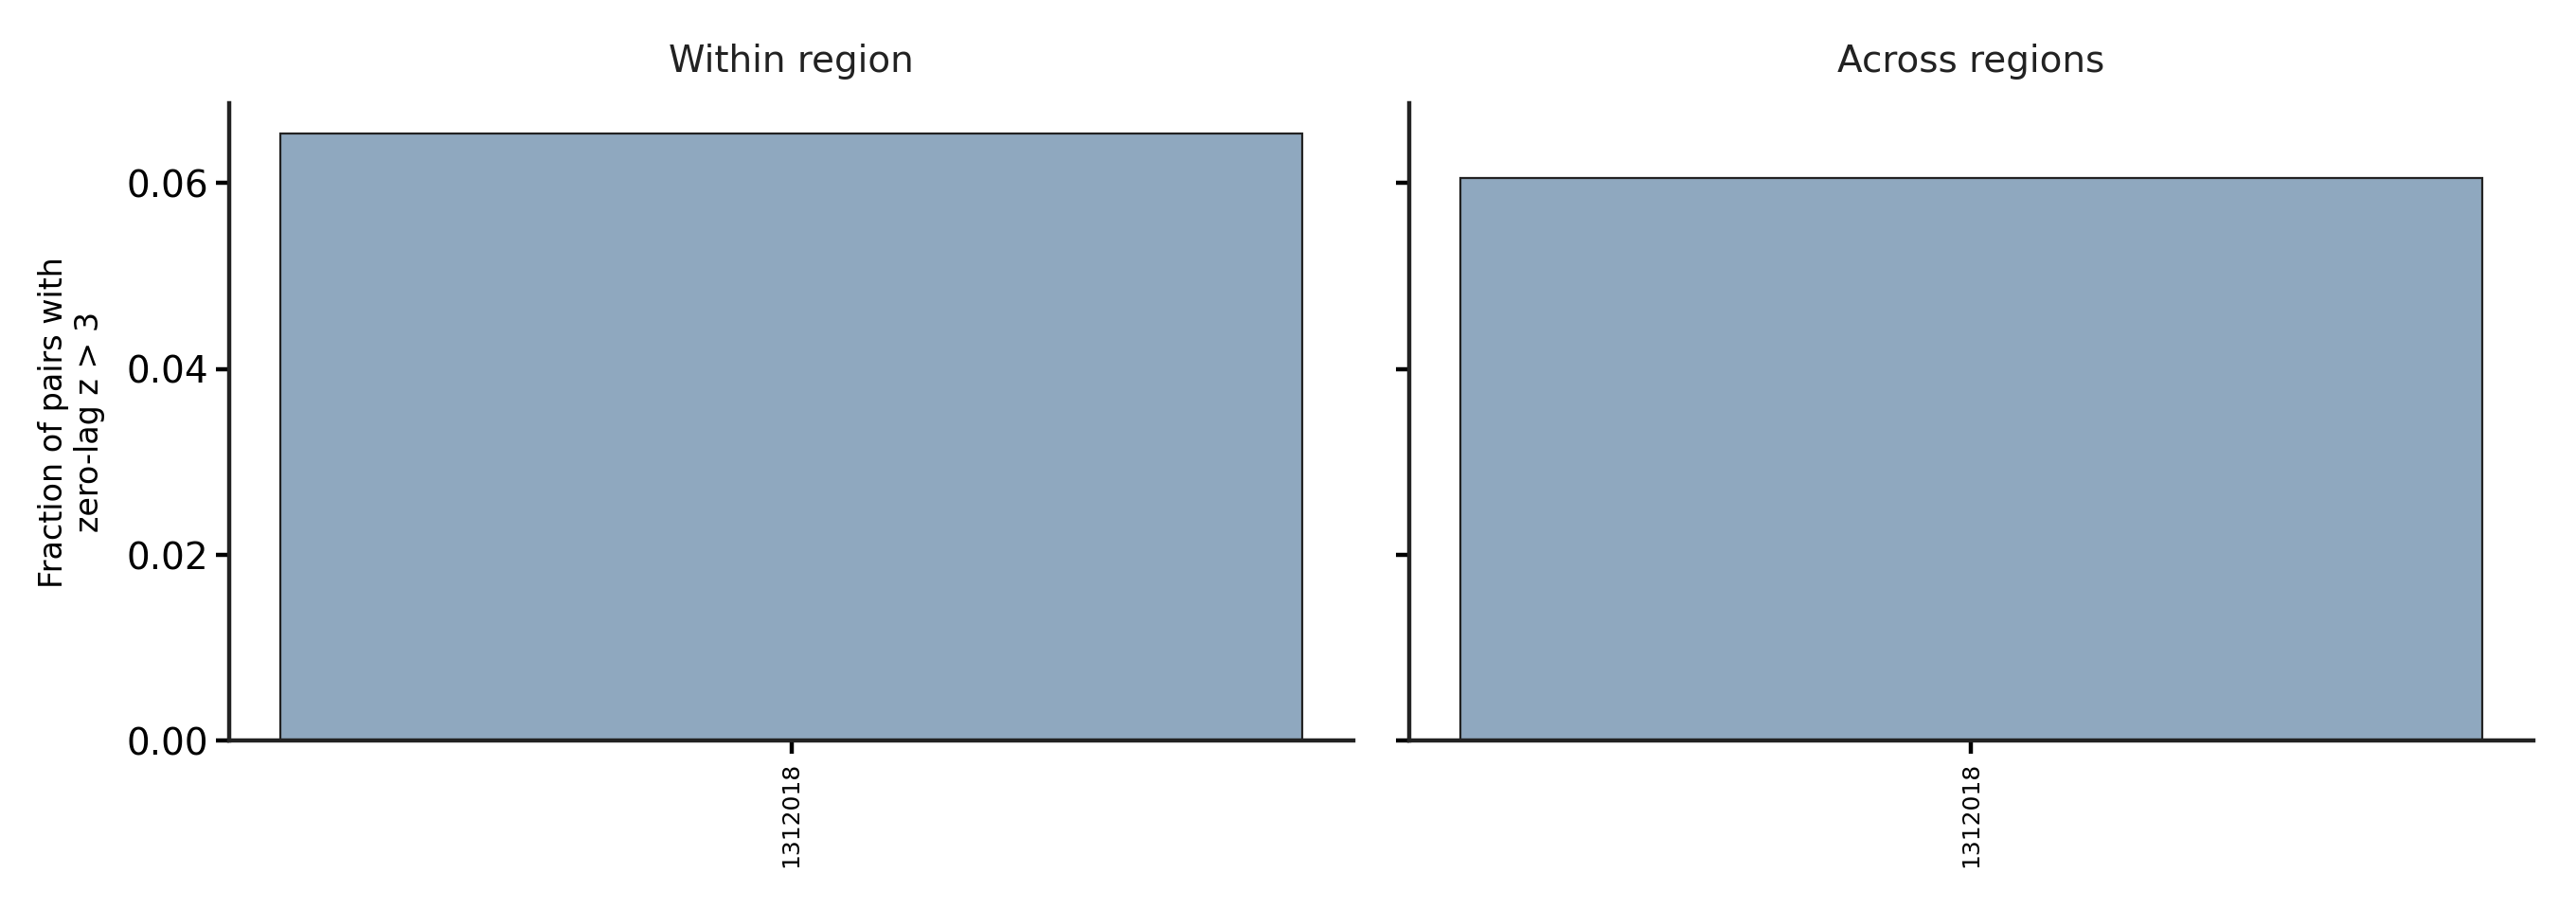

In [13]:
diagnostics = pd.read_csv(SUMMARY_DIR / "zero_lag_diagnostics.csv")
display(diagnostics.round(4))

fig, paths = viz.plot_zero_lag_diagnostics(diagnostics, figs)
display(Image(filename=str(paths["png"])))